

# Imports



In [1]:
import json
import pvlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Select GPU when available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("PyTorch version:", torch.__version__)
print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.14.0+cu130
Selected device: cuda
GPU: NVIDIA GeForce RTX 4070


# PV Class and important functions

In [3]:
# Class
import pvlib

class PVPark:
    def __init__(self, name, latitude, longitude, altitude, tz, tilt, azimuth, nominal_capacity):
        self.location = pvlib.location.Location(latitude=latitude, longitude=longitude, altitude=altitude, tz=tz, name=name)
        self.tilt = tilt
        self.azimuth = azimuth
        self.nominal_capacity = nominal_capacity

    @classmethod
    def from_dataframe(cls, df, index=0):
        row = df.iloc[index]

        lat = row['latitude']
        azimuth = row['azimuth'] if pd.notnull(row['azimuth']) else 180.0
        tilt = row['tilt'] if pd.notnull(row['tilt']) else lat
        altitude = row['altitude'] if pd.notnull(row['altitude']) else None

        return cls(
            name=row['name'],
            latitude=lat,
            longitude=row['longitude'],
            altitude=altitude,
            tz=row['tz'],
            tilt=tilt,
            azimuth=azimuth,
            nominal_capacity=row['nominal_capacity']
        )

In [4]:
def scale_park_data(
    df,
    pv_park,
    feature_columns,
    feature_scaler=None,
    fit_feature_scaler=False,
):
    scaled_df = df.copy()

    # Normalize power using the capacity of the specific park
    scaled_df["active_power"] = (
        scaled_df["active_power"]
        / pv_park.nominal_capacity
    ).clip(lower=0.0, upper=1.0)

    if fit_feature_scaler:
        feature_scaler = MinMaxScaler()

        feature_scaler.fit(
            scaled_df[feature_columns]
        )

    scaled_df[feature_columns] = (
        feature_scaler.transform(
            scaled_df[feature_columns]
        ).astype(np.float32)
    )

    scaled_df["active_power"] = (
        scaled_df["active_power"].astype(np.float32)
    )

    return scaled_df, feature_scaler

In [5]:
def print_correlations(df):
    df_corr = df.corr()
    abs_corr = df_corr['active_power'].abs().sort_values(ascending=False)
    print(abs_corr)

# Load  Training Data

## Load metadata and create park info

In [9]:
base_dir = "/home/sabos/PV-Digital-Twin-Thesis/notebooks"
feature_type = "feature-engineered"
weather_source = "station"


In [10]:
df = pd.read_csv(f"{base_dir}/data/Gasi-CN448/metadata.csv")
# Create PVPark instance from DataFrame
pv_park = PVPark.from_dataframe(df)
print(pv_park.location)
print(pv_park.tilt)
print(pv_park.azimuth)
print(pv_park.nominal_capacity)

Location: 
  name: Gasi-CN448
  latitude: 35.13
  longitude: 25.259
  altitude: 334.0
  tz: Europe/Athens
25.0
180.0
405.0


## Load unprocessed data

In [11]:
df = pd.read_csv(f"{base_dir}/data/Gasi-CN448/{feature_type}/{weather_source}/data.csv")

print(df.head())

          collect_time  active_power  irradiance  poa_global  cos_aoi  dni  \
0  2023-08-12 00:00:00           0.0         0.0         0.0      0.0  0.0   
1  2023-08-12 00:05:00           0.0         0.0         0.0      0.0  0.0   
2  2023-08-12 00:10:00           0.0         0.0         0.0      0.0  0.0   
3  2023-08-12 00:15:00           0.0         0.0         0.0      0.0  0.0   
4  2023-08-12 00:20:00           0.0         0.0         0.0      0.0  0.0   

   dhi  temperature  cos_time  
0  0.0         20.6  1.000000  
1  0.0         20.6  0.999762  
2  0.0         20.6  0.999048  
3  0.0         20.6  0.997859  
4  0.0         20.6  0.996195  


## Create aligned daily tensors

The same function is used for Park A and Park B. It sorts each day and
retains only complete 288-step days.


### Create a scaler and scale values

In [12]:
weather_features_to_scale=["irradiance", "poa_global", "dni", "dhi", "temperature"]

df, weather_scaler = scale_park_data(
    df,
    pv_park,
    weather_features_to_scale,
    fit_feature_scaler=True,
)

print(df.head())

          collect_time  active_power  irradiance  poa_global  cos_aoi  dni  \
0  2023-08-12 00:00:00           0.0         0.0         0.0      0.0  0.0   
1  2023-08-12 00:05:00           0.0         0.0         0.0      0.0  0.0   
2  2023-08-12 00:10:00           0.0         0.0         0.0      0.0  0.0   
3  2023-08-12 00:15:00           0.0         0.0         0.0      0.0  0.0   
4  2023-08-12 00:20:00           0.0         0.0         0.0      0.0  0.0   

   dhi  temperature  cos_time  
0  0.0          0.5  1.000000  
1  0.0          0.5  0.999762  
2  0.0          0.5  0.999048  
3  0.0          0.5  0.997859  
4  0.0          0.5  0.996195  


### Create Tensors

In [13]:
dynamic_features = [
    "irradiance",
    "poa_global",
    "cos_aoi",
    "dni",
    "dhi",
    "temperature",
    "cos_time",
]
SEQUENCE_LENGTH = 288


def create_daily_tensors(frame, dynamic_features, sequence_length=288):
    frame = frame.copy()
    frame["collect_time"] = pd.to_datetime(frame["collect_time"])
    frame = frame.sort_values("collect_time")
    frame["date"] = frame["collect_time"].dt.floor("D")

    daily_conditions = []
    daily_power = []
    daily_dates = []
    dropped_days = 0

    for date, day in frame.groupby("date", sort=True):
        day = day.sort_values("collect_time")
        if len(day) != sequence_length or day["collect_time"].duplicated().any():
            dropped_days += 1
            continue

        daily_conditions.append(
            day[dynamic_features].to_numpy(dtype=np.float32)
        )
        daily_power.append(
            day["active_power"].to_numpy(dtype=np.float32).reshape(sequence_length, 1)
        )
        daily_dates.append(date)

    if not daily_conditions:
        raise ValueError("No complete 288-step days were found in the dataset.")
    if dropped_days:
        print(f"Dropped {dropped_days} incomplete or duplicated day(s).")

    return (
        torch.tensor(np.stack(daily_conditions), dtype=torch.float32),
        torch.tensor(np.stack(daily_power), dtype=torch.float32),
        np.asarray(daily_dates),
    )


X_tensor, Y_tensor, daily_dates = create_daily_tensors(
    df,
    dynamic_features,
    sequence_length=SEQUENCE_LENGTH,
)

print("X shape:", X_tensor.shape)
print("Y shape:", Y_tensor.shape)
print("Number of days:", len(daily_dates))
print("First date:", daily_dates[0])
print("Last date:", daily_dates[-1])


X shape: torch.Size([539, 288, 7])
Y shape: torch.Size([539, 288, 1])
Number of days: 539
First date: 2023-08-12 00:00:00
Last date: 2025-01-31 00:00:00


In [14]:
print("X tensor:", X_tensor.shape)
print("Y tensor:", Y_tensor.shape)
print("Power range:", Y_tensor.min().item(), Y_tensor.max().item())

if Y_tensor.min() < 0 or Y_tensor.max() > 1.05:
    raise ValueError(
        "Active power is not normalized to [0, 1]. "
        "Normalize it before continuing."
    )


X tensor: torch.Size([539, 288, 7])
Y tensor: torch.Size([539, 288, 1])
Power range: 0.0 1.0


# Create Train & Validation Dataset & Dataloaders

In [15]:
number_of_days = len(X_tensor)

train_end = int(0.70 * number_of_days)


X_train = X_tensor[:train_end]
Y_train = Y_tensor[:train_end]

X_validation = X_tensor[train_end:]
Y_validation = Y_tensor[train_end:]


print("Training:", X_train.shape, Y_train.shape)
print("Validation:", X_validation.shape, Y_validation.shape)

Training: torch.Size([377, 288, 7]) torch.Size([377, 288, 1])
Validation: torch.Size([162, 288, 7]) torch.Size([162, 288, 1])


In [16]:
train_dataset = TensorDataset(X_train, Y_train)
validation_dataset = TensorDataset(X_validation,Y_validation,)


BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# The Model

## Conditional Transformer - Generator

This is the only architectural change from the BiLSTM-GAN notebook. The
conditions, day-level noise, critic, WGAN-GP loss, training loop, metrics,
and Park-B testing remain identical.


### Model Class

In [17]:
class ConditionalTransformerGenerator(nn.Module):
    def __init__(
        self,
        condition_size,
        noise_size=16,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2,
        max_sequence_length=288,
    ):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError("d_model must be divisible by nhead.")

        self.noise_size = noise_size
        self.max_sequence_length = max_sequence_length

        self.input_projection = nn.Linear(
            condition_size + noise_size,
            d_model,
        )

        # Learned position information for the 288 five-minute steps.
        self.position_embedding = nn.Parameter(
            torch.zeros(1, max_sequence_length, d_model)
        )
        nn.init.normal_(
            self.position_embedding,
            mean=0.0,
            std=0.02,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )

        self.output_network = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
            nn.Sigmoid(),
        )

    def forward(self, conditions, noise=None):
        batch_size = conditions.size(0)
        sequence_length = conditions.size(1)

        if sequence_length > self.max_sequence_length:
            raise ValueError(
                f"Maximum sequence length is {self.max_sequence_length}, "
                f"received {sequence_length}."
            )

        if noise is None:
            noise = torch.randn(
                batch_size,
                self.noise_size,
                device=conditions.device,
                dtype=conditions.dtype,
            )

        expected_shape = (
            batch_size,
            self.noise_size,
        )

        if noise.shape != expected_shape:
            raise ValueError(
                f"Expected noise shape {expected_shape}, "
                f"received {tuple(noise.shape)}"
            )

        # Keep noise injection identical to the BiLSTM version: one
        # day-level noise vector repeated over all 288 timesteps.
        noise_sequence = noise.unsqueeze(1).expand(
            -1,
            sequence_length,
            -1,
        )

        generator_input = torch.cat(
            [conditions, noise_sequence],
            dim=-1,
        )

        hidden = self.input_projection(generator_input)
        hidden = hidden + self.position_embedding[:, :sequence_length]

        # No causal mask: the entire weather day is known and this task is
        # synthetic profile generation rather than forecasting.
        sequence_output = self.transformer(hidden)
        generated_power = self.output_network(sequence_output)

        return generated_power


### Create the generator

In [18]:
generator = ConditionalTransformerGenerator(
    condition_size=X_train.shape[-1],
    noise_size=16,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.2,
    max_sequence_length=SEQUENCE_LENGTH,
).to(device)


generator_parameters = sum(
    parameter.numel()
    for parameter in generator.parameters()
    if parameter.requires_grad
)

print(generator)
print(
    f"Generator parameters: "
    f"{generator_parameters:,}"
)


ConditionalTransformerGenerator(
  (input_projection): Linear(in_features=23, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (output_network): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
 

/tmp/ipykernel_1328/3596950077.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


### Test the Generator

In [19]:
conditions_batch, real_power_batch = next(
    iter(train_loader)
)

conditions_batch = conditions_batch.to(device)
real_power_batch = real_power_batch.to(device)


with torch.no_grad():
    fake_power_1 = generator(
        conditions_batch
    )

    fake_power_2 = generator(
        conditions_batch
    )


print("Conditions:", conditions_batch.shape)
print("Real power:", real_power_batch.shape)
print("Generated power:", fake_power_1.shape)

print(
    "Generated range:",
    fake_power_1.min().item(),
    fake_power_1.max().item(),
)

mean_difference = (
    fake_power_1 - fake_power_2
).abs().mean().item()

print(
    "Difference between two generations:",
    mean_difference,
)

Conditions: torch.Size([32, 288, 7])
Real power: torch.Size([32, 288, 1])
Generated power: torch.Size([32, 288, 1])
Generated range: 0.344316691160202 0.6878791451454163
Difference between two generations: 0.049002595245838165


## Conditional 1D-CNN Critic

### Model Class

In [20]:
class ConditionalCNNCritic(nn.Module):
    def __init__(
        self,
        condition_size,
        power_size=1,
    ):
        super().__init__()

        input_channels = (
            condition_size + power_size
        )

        self.network = nn.Sequential(
            nn.Conv1d(
                in_channels=input_channels,
                out_channels=32,
                kernel_size=7,
                stride=2,
                padding=3,
            ),
            nn.LeakyReLU(0.2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                stride=2,
                padding=2,
            ),
            nn.LeakyReLU(0.2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                stride=2,
                padding=2,
            ),
            nn.LeakyReLU(0.2),

            nn.Conv1d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.LeakyReLU(0.2),

            # Convert the remaining temporal dimension to one value
            nn.AdaptiveAvgPool1d(1),

            nn.Flatten(),

            nn.Linear(256, 1),
        )

    def forward(
        self,
        conditions,
        power_profile,
    ):
        if conditions.ndim != 3:
            raise ValueError(
                "conditions must have shape "
                "[batch, sequence, features]"
            )

        if power_profile.ndim != 3:
            raise ValueError(
                "power_profile must have shape "
                "[batch, sequence, 1]"
            )

        if conditions.shape[:2] != power_profile.shape[:2]:
            raise ValueError(
                "Conditions and power must have matching "
                "batch and sequence dimensions."
            )

        # [batch, sequence, conditions + power]
        critic_input = torch.cat(
            [
                conditions,
                power_profile,
            ],
            dim=-1,
        )

        # Conv1d requires:
        # [batch, channels, sequence]
        critic_input = critic_input.transpose(
            1,
            2,
        )

        score = self.network(critic_input)

        return score

### Create the critic

In [21]:
critic = ConditionalCNNCritic(
    condition_size=X_train.shape[-1],
    power_size=1,
).to(device)


critic_parameters = sum(
    parameter.numel()
    for parameter in critic.parameters()
    if parameter.requires_grad
)

print(critic)
print(
    f"Critic parameters: {critic_parameters:,}"
)

ConditionalCNNCritic(
  (network): Sequential(
    (0): Conv1d(8, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): LeakyReLU(negative_slope=0.2)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
    (7): LeakyReLU(negative_slope=0.2)
    (8): AdaptiveAvgPool1d(output_size=1)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=256, out_features=1, bias=True)
  )
)
Critic parameters: 152,033


### Test real and generated profiles

In [22]:
conditions_batch, real_power_batch = next(
    iter(train_loader)
)

conditions_batch = conditions_batch.to(device)
real_power_batch = real_power_batch.to(device)


with torch.no_grad():
    fake_power_batch = generator(
        conditions_batch
    )

    real_scores = critic(
        conditions_batch,
        real_power_batch,
    )

    fake_scores = critic(
        conditions_batch,
        fake_power_batch,
    )


print("Conditions:", conditions_batch.shape)
print("Real power:", real_power_batch.shape)
print("Fake power:", fake_power_batch.shape)

print("Real scores:", real_scores.shape)
print("Fake scores:", fake_scores.shape)

print(
    "Mean real score:",
    real_scores.mean().item(),
)

print(
    "Mean fake score:",
    fake_scores.mean().item(),
)

Conditions: torch.Size([32, 288, 7])
Real power: torch.Size([32, 288, 1])
Fake power: torch.Size([32, 288, 1])
Real scores: torch.Size([32, 1])
Fake scores: torch.Size([32, 1])
Mean real score: -0.04195111244916916
Mean fake score: -0.042880937457084656


## Gradient penalty

In [23]:
def calculate_gradient_penalty(
    critic,
    conditions,
    real_power,
    fake_power,
):
    batch_size = real_power.size(0)

    # One interpolation weight for each complete daily profile
    alpha = torch.rand(
        batch_size,
        1,
        1,
        device=real_power.device,
    )

    interpolated_power = (
        alpha * real_power
        + (1 - alpha) * fake_power
    )

    interpolated_power.requires_grad_(True)

    interpolated_scores = critic(
        conditions,
        interpolated_power,
    )

    gradients = torch.autograd.grad(
        outputs=interpolated_scores,
        inputs=interpolated_power,
        grad_outputs=torch.ones_like(
            interpolated_scores
        ),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    # [batch, 288, 1] → [batch, 288]
    gradients = gradients.reshape(
        batch_size,
        -1,
    )

    gradient_norm = gradients.norm(
        p=2,
        dim=1,
    )

    gradient_penalty = (
        (gradient_norm - 1) ** 2
    ).mean()

    return gradient_penalty

### Test it on one batch

In [24]:
conditions_batch, real_power_batch = next(
    iter(train_loader)
)

conditions_batch = conditions_batch.to(device)
real_power_batch = real_power_batch.to(device)


# We do not need generator gradients during this test
with torch.no_grad():
    fake_power_batch = generator(
        conditions_batch
    )


gradient_penalty = calculate_gradient_penalty(
    critic,
    conditions_batch,
    real_power_batch,
    fake_power_batch,
)


print(
    "Gradient penalty:",
    gradient_penalty.item(),
)

print(
    "Requires gradient:",
    gradient_penalty.requires_grad,
)

assert gradient_penalty.ndim == 0
assert gradient_penalty.item() >= 0
assert gradient_penalty.requires_grad

Gradient penalty: 0.9972720146179199
Requires gradient: True


/home/sabos/PV-Digital-Twin-Thesis/notebooks/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:1072: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:410.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


### Calculate one critic loss

In [25]:
LAMBDA_GP = 10.0


real_scores = critic(
    conditions_batch,
    real_power_batch,
)

fake_scores = critic(
    conditions_batch,
    fake_power_batch.detach(),
)


wasserstein_distance = (
    real_scores.mean()
    - fake_scores.mean()
)

critic_loss = (
    fake_scores.mean()
    - real_scores.mean()
    + LAMBDA_GP * gradient_penalty
)


print(
    "Mean real score:",
    real_scores.mean().item(),
)

print(
    "Mean fake score:",
    fake_scores.mean().item(),
)

print(
    "Estimated Wasserstein distance:",
    wasserstein_distance.item(),
)

print(
    "Critic loss:",
    critic_loss.item(),
)

Mean real score: -0.04185250401496887
Mean fake score: -0.04279712587594986
Estimated Wasserstein distance: 0.0009446218609809875
Critic loss: 9.97177505493164


## Training hyperparameters


The following values control WGAN-GP training. The model architecture and
Wasserstein objective are unchanged.


In [26]:
LEARNING_RATE = 1e-3
LAMBDA_GP = 5.0
CRITIC_STEPS = 5
NUM_EPOCHS = 100  # Initial test run

In [27]:
generator_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.0, 0.9),
)

critic_optimizer = torch.optim.Adam(
    critic.parameters(),
    lr=LEARNING_RATE,
    betas=(0.0, 0.9),
)

## Train the GAN

### Gan Training Function

In [28]:
def train_wgan_epoch(
    generator,
    critic,
    train_loader,
    generator_optimizer,
    critic_optimizer,
    lambda_gp=10.0,
    critic_steps=5,
):
    generator.train()
    critic.train()

    total_generator_loss = 0.0
    total_critic_loss = 0.0
    total_gradient_penalty = 0.0
    total_wasserstein_estimate = 0.0

    generator_updates = 0
    critic_updates = 0

    for conditions, real_power in train_loader:
        conditions = conditions.to(device)
        real_power = real_power.to(device)

        # ---------------------------------------
        # 1. Train the critic several times
        # ---------------------------------------

        for _ in range(critic_steps):
            critic_optimizer.zero_grad(
                set_to_none=True
            )

            # Generator must not receive gradients
            # during critic training
            with torch.no_grad():
                fake_power = generator(conditions)

            real_scores = critic(
                conditions,
                real_power,
            )

            fake_scores = critic(
                conditions,
                fake_power,
            )

            gradient_penalty = (
                calculate_gradient_penalty(
                    critic,
                    conditions,
                    real_power,
                    fake_power,
                )
            )

            critic_loss = (
                fake_scores.mean()
                - real_scores.mean()
                + lambda_gp * gradient_penalty
            )

            critic_loss.backward()

            critic_optimizer.step()

            wasserstein_estimate = (
                real_scores.mean()
                - fake_scores.mean()
            )

            total_critic_loss += critic_loss.item()
            total_gradient_penalty += (
                gradient_penalty.item()
            )
            total_wasserstein_estimate += (
                wasserstein_estimate.item()
            )

            critic_updates += 1

        # ---------------------------------------
        # 2. Train the generator once
        # ---------------------------------------

        # Temporarily freeze critic parameters.
        # Gradients still flow through the critic
        # into the generated power profile.
        for parameter in critic.parameters():
            parameter.requires_grad_(False)

        generator_optimizer.zero_grad(
            set_to_none=True
        )

        fake_power = generator(conditions)

        fake_scores = critic(
            conditions,
            fake_power,
        )

        generator_loss = -fake_scores.mean()

        generator_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            generator.parameters(),
            max_norm=1.0,
        )

        generator_optimizer.step()

        # Reactivate critic parameters
        for parameter in critic.parameters():
            parameter.requires_grad_(True)

        total_generator_loss += (
            generator_loss.item()
        )

        generator_updates += 1

    metrics = {
        "generator_loss": (
            total_generator_loss
            / generator_updates
        ),
        "critic_loss": (
            total_critic_loss
            / critic_updates
        ),
        "gradient_penalty": (
            total_gradient_penalty
            / critic_updates
        ),
        "wasserstein_estimate": (
            total_wasserstein_estimate
            / critic_updates
        ),
    }

    return metrics

### Training

In [29]:
training_history = {
    "generator_loss": [],
    "critic_loss": [],
    "gradient_penalty": [],
    "wasserstein_estimate": [],
}


for epoch in range(1, NUM_EPOCHS + 1):
    metrics = train_wgan_epoch(
        generator=generator,
        critic=critic,
        train_loader=train_loader,
        generator_optimizer=generator_optimizer,
        critic_optimizer=critic_optimizer,
        lambda_gp=LAMBDA_GP,
        critic_steps=CRITIC_STEPS,
    )

    for metric_name, value in metrics.items():
        training_history[metric_name].append(value)

    print(
        f"Epoch {epoch:03d} | "
        f"G loss: {metrics['generator_loss']:.4f} | "
        f"C loss: {metrics['critic_loss']:.4f} | "
        f"GP: {metrics['gradient_penalty']:.4f} | "
        f"W distance: "
        f"{metrics['wasserstein_estimate']:.4f}"
    )

Epoch 001 | G loss: 9.1041 | C loss: -3.7163 | GP: 0.2611 | W distance: 5.0221
Epoch 002 | G loss: 12.4388 | C loss: -2.4841 | GP: 0.0887 | W distance: 2.9276
Epoch 003 | G loss: 19.0115 | C loss: -1.0307 | GP: 0.0509 | W distance: 1.2854
Epoch 004 | G loss: 23.0099 | C loss: -1.1514 | GP: 0.0652 | W distance: 1.4774
Epoch 005 | G loss: 17.9221 | C loss: -1.0539 | GP: 0.0518 | W distance: 1.3130
Epoch 006 | G loss: 17.0331 | C loss: -0.8558 | GP: 0.0506 | W distance: 1.1087
Epoch 007 | G loss: 14.4726 | C loss: -0.7896 | GP: 0.0474 | W distance: 1.0265
Epoch 008 | G loss: 12.0944 | C loss: -0.7457 | GP: 0.0473 | W distance: 0.9824
Epoch 009 | G loss: 9.9311 | C loss: -0.7026 | GP: 0.0398 | W distance: 0.9015
Epoch 010 | G loss: 7.7416 | C loss: -0.6503 | GP: 0.0433 | W distance: 0.8670
Epoch 011 | G loss: 7.1160 | C loss: -0.6469 | GP: 0.0361 | W distance: 0.8275
Epoch 012 | G loss: 8.0681 | C loss: -0.5732 | GP: 0.0323 | W distance: 0.7348
Epoch 013 | G loss: 8.4377 | C loss: -0.5680 

### Plot the training history

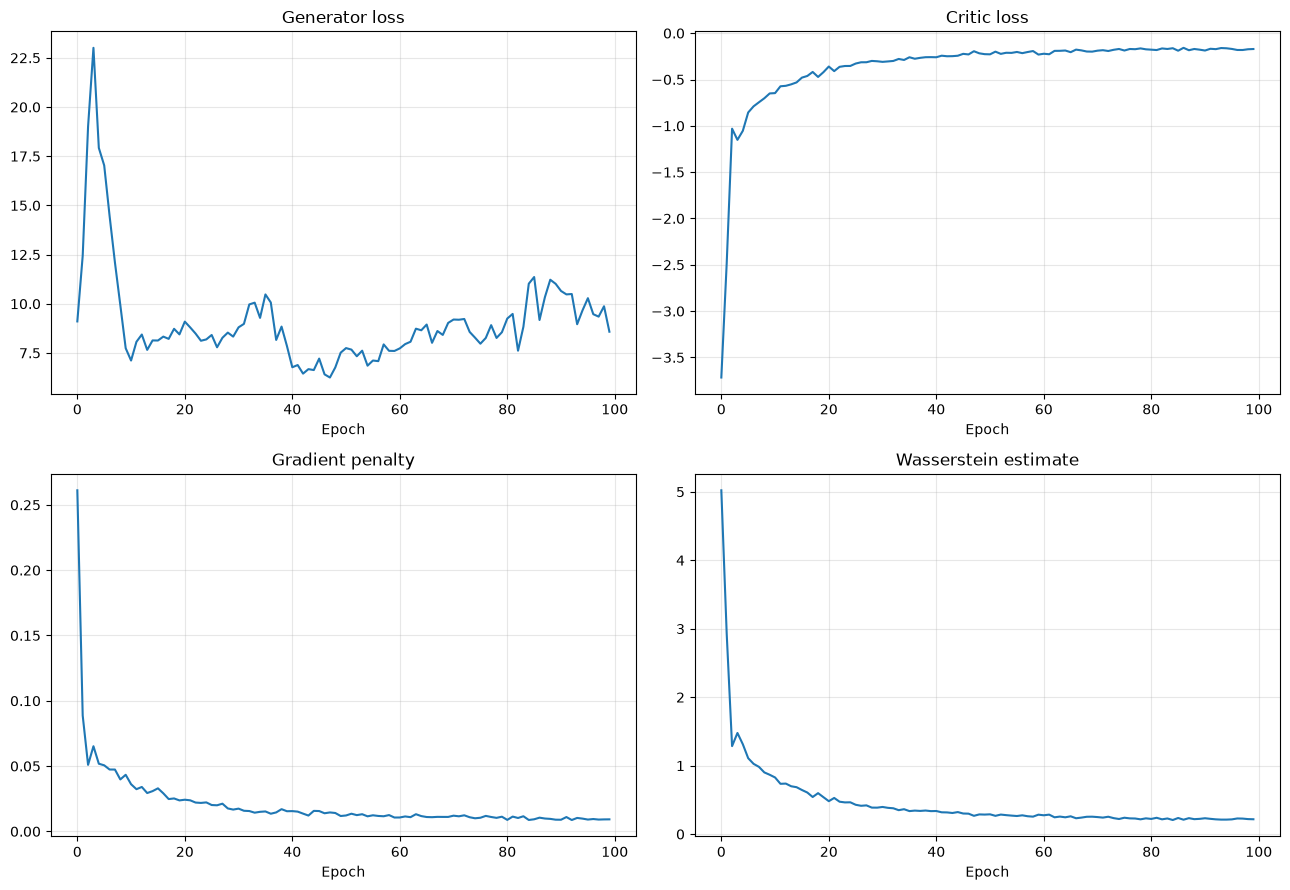

In [30]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
)

axes[0, 0].plot(
    training_history["generator_loss"]
)
axes[0, 0].set_title("Generator loss")

axes[0, 1].plot(
    training_history["critic_loss"]
)
axes[0, 1].set_title("Critic loss")

axes[1, 0].plot(
    training_history["gradient_penalty"]
)
axes[1, 0].set_title("Gradient penalty")

axes[1, 1].plot(
    training_history["wasserstein_estimate"]
)
axes[1, 1].set_title("Wasserstein estimate")

for axis in axes.flat:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate the Transformer-GAN

GAN evaluation uses an ensemble of profiles generated with different
noise vectors under identical weather conditions. Metrics on the
ensemble mean measure accuracy; CRPS, coverage, width, and synthetic
standard deviation measure the generated distribution.


In [31]:
@torch.no_grad()
def generate_ensemble(
    generator,
    conditions,
    number_of_scenarios=20,
    batch_size=64,
):
    # Output shape: [scenarios, days, 288, 1]
    generator.eval()
    scenarios = []

    for _ in range(number_of_scenarios):
        generated_batches = []
        for start in range(0, len(conditions), batch_size):
            condition_batch = conditions[start : start + batch_size].to(device)
            generated_batches.append(generator(condition_batch).cpu())
        scenarios.append(torch.cat(generated_batches, dim=0))

    return torch.stack(scenarios, dim=0).numpy()


def calculate_synthetic_metrics(
    real_power,
    generated_scenarios,
    conditions,
    nominal_capacity,
    interval=0.90,
):
    real_power = np.asarray(real_power)
    generated_scenarios = np.asarray(generated_scenarios)
    conditions = np.asarray(conditions)

    generated_mean = generated_scenarios.mean(axis=0)
    alpha = 1.0 - interval
    lower = np.quantile(generated_scenarios, alpha / 2.0, axis=0)
    upper = np.quantile(generated_scenarios, 1.0 - alpha / 2.0, axis=0)
    inside = (real_power >= lower) & (real_power <= upper)

    # Ensemble CRPS without allocating a large [S,S,D,T,1] array.
    observation_term = np.abs(
        generated_scenarios - real_power[None, ...]
    ).mean()
    pairwise_mean = 0.0
    for first_scenario in generated_scenarios:
        for second_scenario in generated_scenarios:
            pairwise_mean += np.abs(
                first_scenario - second_scenario
            ).mean()
    pairwise_mean /= generated_scenarios.shape[0] ** 2
    crps = observation_term - 0.5 * pairwise_mean

    real_flat = real_power.reshape(-1)
    mean_flat = generated_mean.reshape(-1)
    normalized_mae = mean_absolute_error(real_flat, mean_flat)
    normalized_rmse = np.sqrt(mean_squared_error(real_flat, mean_flat))

    irradiance_condition_index = dynamic_features.index("irradiance")
    irradiance_scaler_index = weather_features_to_scale.index("irradiance")
    scaled_zero_irradiance = weather_scaler.min_[irradiance_scaler_index]
    daylight = (
        conditions[:, :, irradiance_condition_index]
        > scaled_zero_irradiance + 1e-6
    )[..., None]

    daily_daylight_coverage = []
    for day_index in range(len(real_power)):
        day_mask = daylight[day_index, :, 0]
        if day_mask.any():
            daily_daylight_coverage.append(
                inside[day_index, day_mask, 0].mean()
            )

    real_energy = real_power.sum(axis=1).squeeze(-1) / 12.0
    generated_energy = generated_mean.sum(axis=1).squeeze(-1) / 12.0

    metrics = {
        "MAE (normalized)": normalized_mae,
        "RMSE (normalized)": normalized_rmse,
        "R² (ensemble mean)": r2_score(real_flat, mean_flat),
        "MAE (physical power)": normalized_mae * nominal_capacity,
        "RMSE (physical power)": normalized_rmse * nominal_capacity,
        "CRPS": crps,
        f"{int(interval * 100)}% point coverage": inside.mean(),
        f"{int(interval * 100)}% interval width": (upper - lower).mean(),
        "Mean synthetic std": generated_scenarios.std(axis=0).mean(),
        "Daily energy MAE (normalized hours)": np.abs(
            real_energy - generated_energy
        ).mean(),
        "Daily energy MAE (physical)": np.abs(
            real_energy - generated_energy
        ).mean() * nominal_capacity,
        "Ramp MAE": np.abs(
            np.diff(real_power, axis=1)
            - np.diff(generated_mean, axis=1)
        ).mean(),
        f"{int(interval * 100)}% daytime coverage": inside[daylight].mean(),
        "Mean daily daylight coverage": np.mean(daily_daylight_coverage),
        "Profile coverage (>=90% daylight points)": np.mean(
            np.asarray(daily_daylight_coverage) >= 0.90
        ),
    }

    return pd.Series(metrics), generated_mean, lower, upper


In [32]:
def plot_synthetic_day(
    day_index,
    dates,
    conditions,
    real_power,
    generated_scenarios,
    generated_mean,
    lower,
    upper,
    park_name,
):
    if not 0 <= day_index < len(real_power):
        raise IndexError(
            f"day_index must be between 0 and {len(real_power) - 1}."
        )

    hours = np.arange(SEQUENCE_LENGTH) / 12.0
    fig, power_axis = plt.subplots(figsize=(13, 6))

    for profile in generated_scenarios[:, day_index, :, 0]:
        power_axis.plot(hours, profile, color="gray", alpha=0.10)

    power_axis.fill_between(
        hours,
        lower[day_index, :, 0],
        upper[day_index, :, 0],
        color="tab:blue",
        alpha=0.22,
        label="5–95% synthetic interval",
    )
    power_axis.plot(
        hours,
        real_power[day_index, :, 0],
        color="tab:red",
        linewidth=2,
        label="Real power",
    )
    power_axis.plot(
        hours,
        generated_mean[day_index, :, 0],
        color="tab:blue",
        linewidth=2,
        label="Mean synthetic power",
    )
    power_axis.set_xlabel("Hour")
    power_axis.set_ylabel("Normalized active power")
    power_axis.set_ylim(-0.05, 1.05)
    power_axis.grid(alpha=0.3)

    irradiance_index = dynamic_features.index("irradiance")
    irradiance_axis = power_axis.twinx()
    irradiance_axis.plot(
        hours,
        conditions[day_index, :, irradiance_index],
        color="tab:green",
        linestyle="--",
        alpha=0.60,
        label="Scaled irradiance",
    )
    irradiance_axis.set_ylabel("Scaled irradiance")

    lines_1, labels_1 = power_axis.get_legend_handles_labels()
    lines_2, labels_2 = irradiance_axis.get_legend_handles_labels()
    power_axis.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
    power_axis.set_title(f"{park_name} — {dates[day_index]}")
    plt.tight_layout()
    plt.show()


## Park A validation results


In [33]:
NUMBER_OF_SCENARIOS = 20

validation_scenarios = generate_ensemble(
    generator,
    X_validation,
    number_of_scenarios=NUMBER_OF_SCENARIOS,
)
(
    validation_metrics,
    validation_mean,
    validation_lower,
    validation_upper,
) = calculate_synthetic_metrics(
    real_power=Y_validation.numpy(),
    generated_scenarios=validation_scenarios,
    conditions=X_validation.numpy(),
    nominal_capacity=pv_park.nominal_capacity,
)

display(validation_metrics.to_frame("Park A validation"))


,Park A validation
MAE (normalized),0.018540
RMSE (normalized),0.042343
R² (ensemble mean),0.977919
MAE (physical power),7.508536
RMSE (physical power),17.148866
CRPS,0.014406
90% point coverage,0.308642
90% interval width,0.041372
Mean synthetic std,0.014194
Daily energy MAE (normalized hours),0.317532


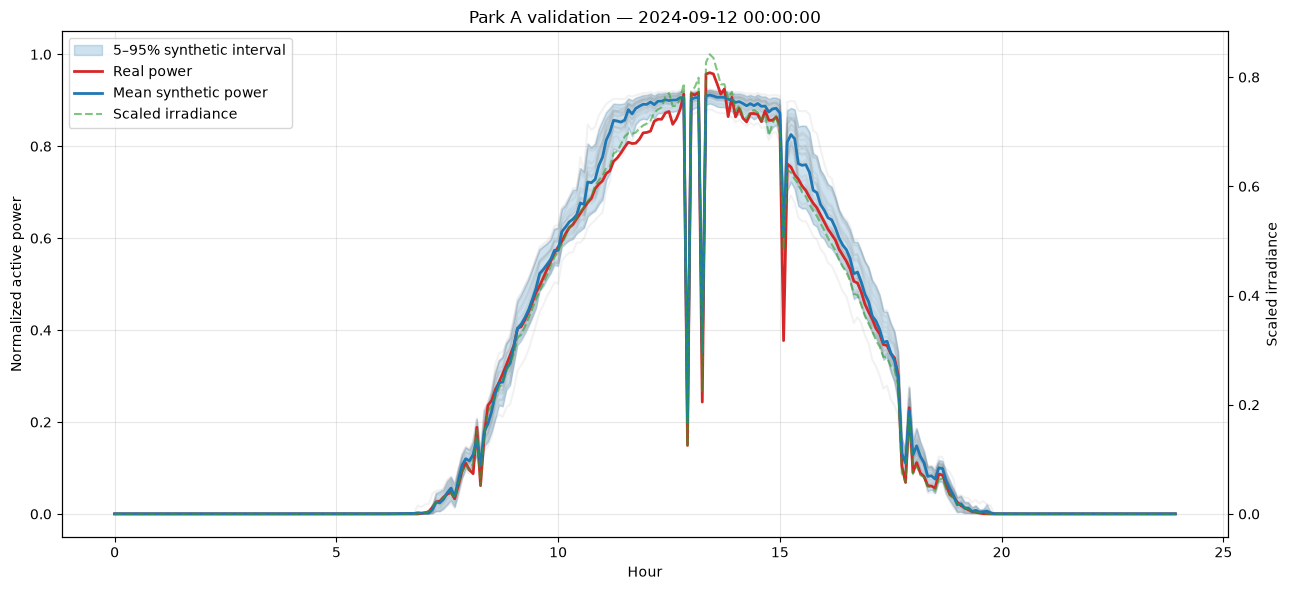

In [34]:
validation_dates = daily_dates[train_end:]
plot_synthetic_day(
    day_index=min(20, len(Y_validation) - 1),
    dates=validation_dates,
    conditions=X_validation.numpy(),
    real_power=Y_validation.numpy(),
    generated_scenarios=validation_scenarios,
    generated_mean=validation_mean,
    lower=validation_lower,
    upper=validation_upper,
    park_name="Park A validation",
)


# Test on Park B

Park B must use the weather scaler fitted on Park A. Its active power is
normalized with Park B's own nominal capacity. Active power remains an
evaluation target only and is never included in the generator input.


In [35]:
from pathlib import Path

PARK_B_ID = "Sarafali-CN506"
park_b_metadata_path = f"{base_dir}/data/{PARK_B_ID}/metadata.csv"
park_b_data_candidates = [
    Path(base_dir) / "data" / PARK_B_ID / feature_type / weather_source / "curtailed" / "data.csv",
    Path(base_dir) / "data" / PARK_B_ID / feature_type / weather_source / "data.csv",
]
park_b_data_path = next(
    (path for path in park_b_data_candidates if path.exists()),
    None,
)
if park_b_data_path is None:
    attempted = "\n".join(str(path) for path in park_b_data_candidates)
    raise FileNotFoundError(
        "Park B data was not found. Checked:\n" + attempted
    )

park_b_metadata = pd.read_csv(park_b_metadata_path)
park_b = PVPark.from_dataframe(park_b_metadata)
park_b_raw = pd.read_csv(park_b_data_path)

missing_features = sorted(
    set(dynamic_features + ["active_power", "collect_time"])
    - set(park_b_raw.columns)
)
if missing_features:
    raise ValueError(
        f"Park B is missing required columns: {missing_features}"
    )

print(park_b.location)
print("Park B nominal capacity:", park_b.nominal_capacity)
print("Park B data path:", park_b_data_path)
display(park_b_raw.head())


Location: 
  name: Sarafali-CN506
  latitude: 35.13
  longitude: 25.259
  altitude: 334.0
  tz: Europe/Athens
Park B nominal capacity: 1000.0
Park B data path: /home/sabos/PV-Digital-Twin-Thesis/notebooks/data/Sarafali-CN506/feature-engineered/station/data.csv


,collect_time,active_power,irradiance,poa_global,cos_aoi,dni,dhi,temperature,cos_time
0,2023-09-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,22.3,1.000000
1,2023-09-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0.999762
2,2023-09-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,22.8,0.999048
3,2023-09-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,22.4,0.997859
4,2023-09-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,22.2,0.996195


## Apply Park A scaling and build Park B daily tensors


In [36]:
park_b_scaled, _ = scale_park_data(
    park_b_raw,
    park_b,
    feature_columns=weather_features_to_scale,
    feature_scaler=weather_scaler,   # fitted on Park A; do not refit
    fit_feature_scaler=False,
)

X_park_b, Y_park_b, park_b_dates = create_daily_tensors(
    park_b_scaled,
    dynamic_features,
    sequence_length=SEQUENCE_LENGTH,
)

print("Park B conditions:", X_park_b.shape)
print("Park B real power:", Y_park_b.shape)
print("Park B target range:", Y_park_b.min().item(), Y_park_b.max().item())


Park B conditions: torch.Size([182, 288, 7])
Park B real power: torch.Size([182, 288, 1])
Park B target range: 0.0 1.0


## Generate and evaluate Park B synthetic profiles


In [37]:
park_b_scenarios = generate_ensemble(
    generator,
    X_park_b,
    number_of_scenarios=NUMBER_OF_SCENARIOS,
)
(
    park_b_metrics,
    park_b_mean,
    park_b_lower,
    park_b_upper,
) = calculate_synthetic_metrics(
    real_power=Y_park_b.numpy(),
    generated_scenarios=park_b_scenarios,
    conditions=X_park_b.numpy(),
    nominal_capacity=park_b.nominal_capacity,
)

display(park_b_metrics.to_frame("Park B test"))


,Park B test
MAE (normalized),0.019910
RMSE (normalized),0.050304
R² (ensemble mean),0.963948
MAE (physical power),19.909954
RMSE (physical power),50.303801
CRPS,0.016057
90% point coverage,0.302942
90% interval width,0.040914
Mean synthetic std,0.014068
Daily energy MAE (normalized hours),0.319055


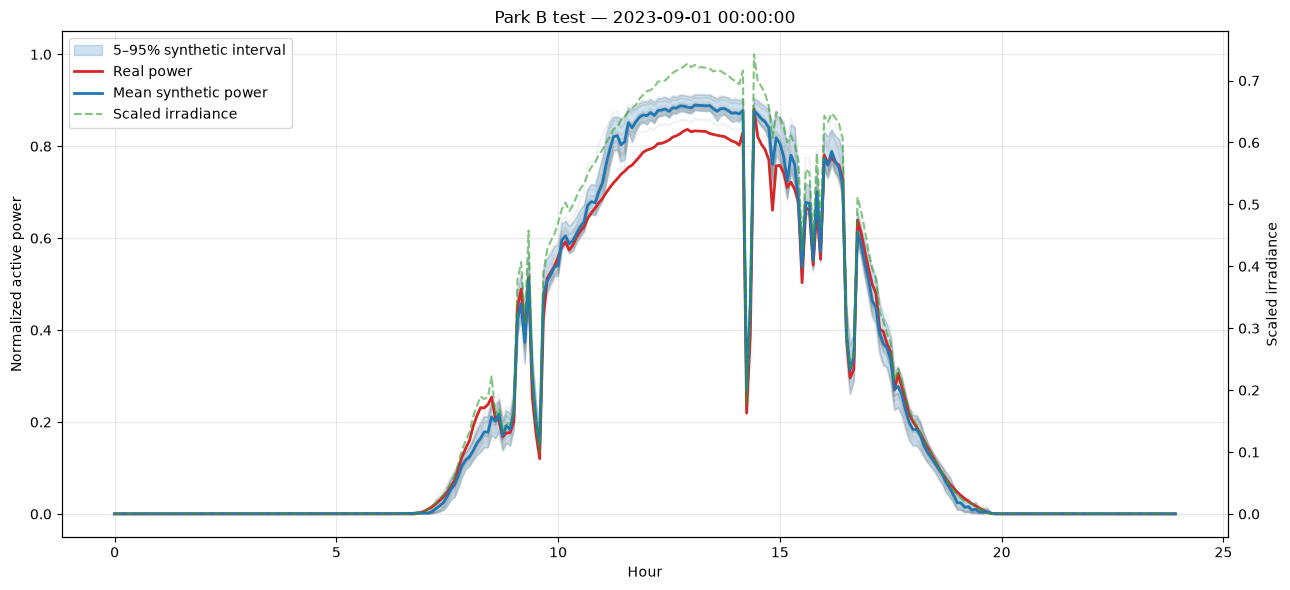

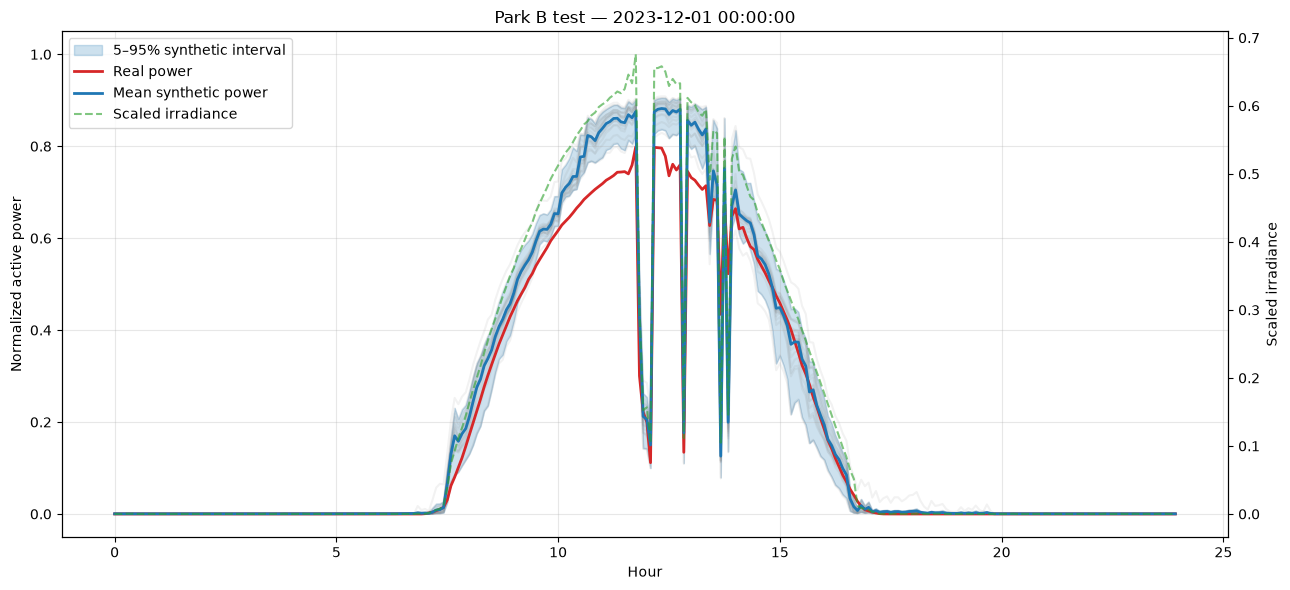

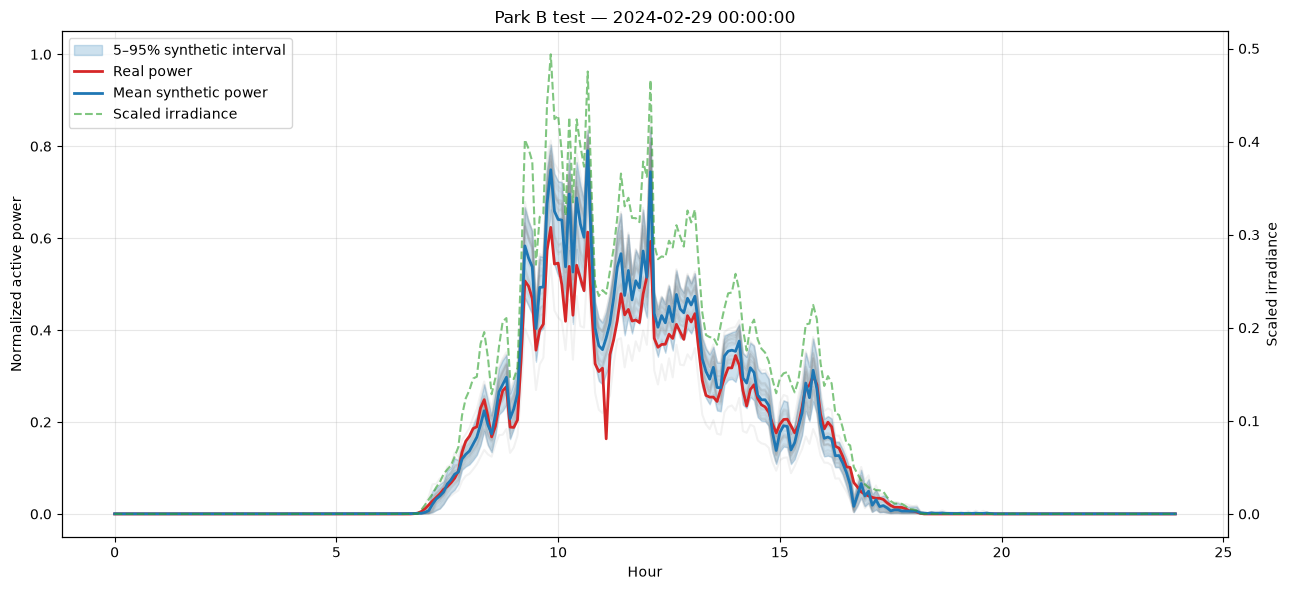

In [38]:
selected_park_b_days = sorted(
    set([0, len(Y_park_b) // 2, len(Y_park_b) - 1])
)

for day_index in selected_park_b_days:
    plot_synthetic_day(
        day_index=day_index,
        dates=park_b_dates,
        conditions=X_park_b.numpy(),
        real_power=Y_park_b.numpy(),
        generated_scenarios=park_b_scenarios,
        generated_mean=park_b_mean,
        lower=park_b_lower,
        upper=park_b_upper,
        park_name="Park B test",
    )


## Optional: save Park B synthetic data


In [39]:
# Shape: [scenarios, days, 288, 1]
park_b_scenarios_physical = (
    park_b_scenarios * park_b.nominal_capacity
)

# Uncomment to save the complete ensemble.
# output_path = f"{base_dir}/data/Predictions/Transformer_GAN_ParkB.npy"
# np.save(output_path, park_b_scenarios_physical)
# print("Saved:", output_path)

print("Normalized ensemble shape:", park_b_scenarios.shape)
print("Physical ensemble shape:", park_b_scenarios_physical.shape)


Normalized ensemble shape: (20, 182, 288, 1)
Physical ensemble shape: (20, 182, 288, 1)
